# Iris Flower Classification

## Objective

The objective of this project is to classify Iris flowers into three
species: Setosa, Versicolor, and Virginica, based on their sepal and
petal measurements.

## Dataset

The Iris dataset from scikit-learn is used in this project. The dataset
contains 150 samples and four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target variable contains three Iris species: Setosa, Versicolor,
and Virginica.

In [37]:
from sklearn.datasets import load_iris

iris = load_iris()

print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [38]:
import pandas as pd

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [39]:
print("Dataset size:")
print(df.shape)

print("\nDataset information:")
df.info()

Dataset size:
(150, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [40]:
print("Missing values:")

print(df.isnull().sum())

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [41]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


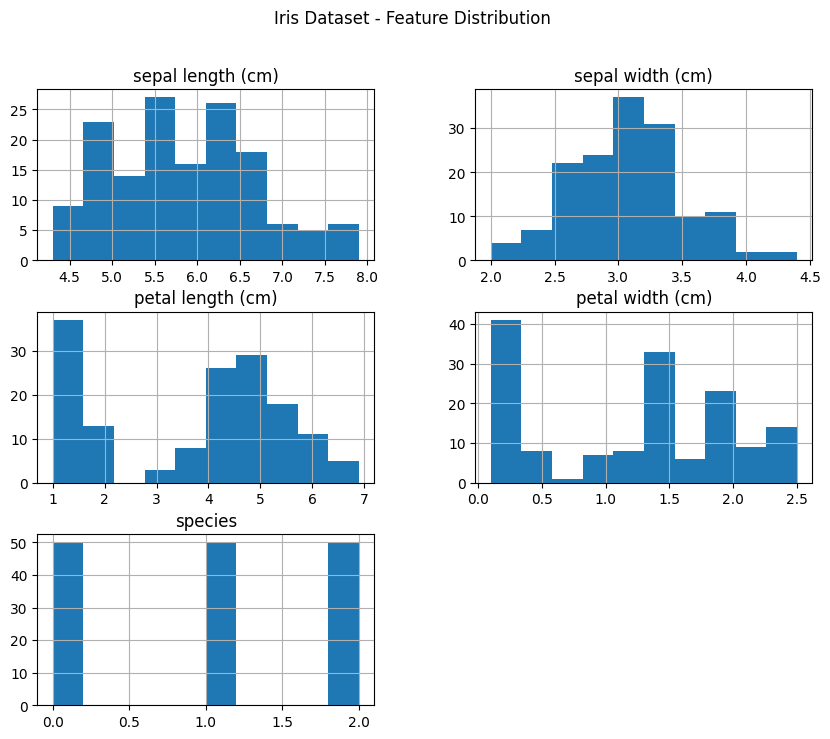

In [42]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8))

plt.suptitle("Iris Dataset - Feature Distribution")
plt.show()

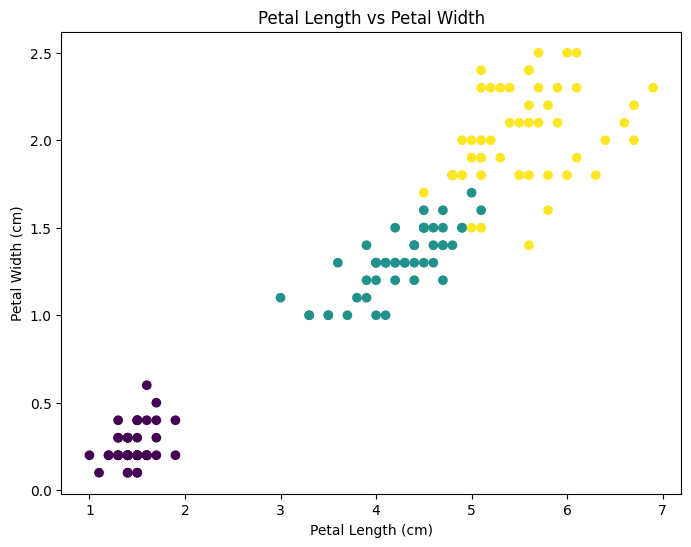

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["species"]
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")

plt.show()

In [44]:
X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [48]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.33%


In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [51]:
from sklearn.metrics import classification_report

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



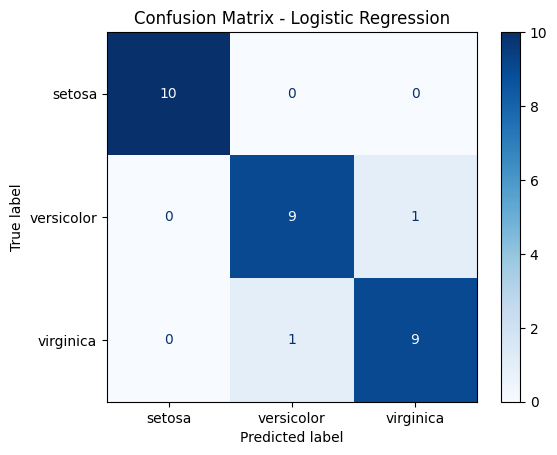

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [53]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 93.33%


In [54]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 96.67%


In [55]:
model_names = [
    "Logistic Regression",
    "KNN",
    "Decision Tree"
]

accuracies = [
    accuracy * 100,
    knn_accuracy * 100,
    tree_accuracy * 100
]

for name, acc in zip(model_names, accuracies):
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 93.33%
KNN: 93.33%
Decision Tree: 96.67%


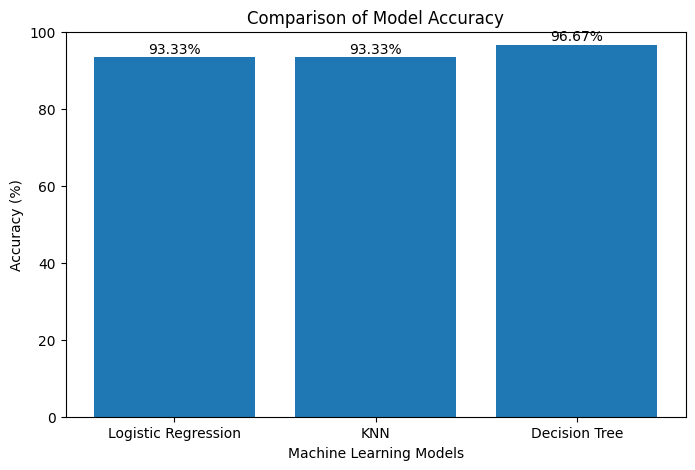

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(model_names, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Model Accuracy")

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

In [57]:
print("Decision Tree Classification Report:")
print()

print(
    classification_report(
        y_test,
        tree_pred,
        target_names=iris.target_names
    )
)

Decision Tree Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



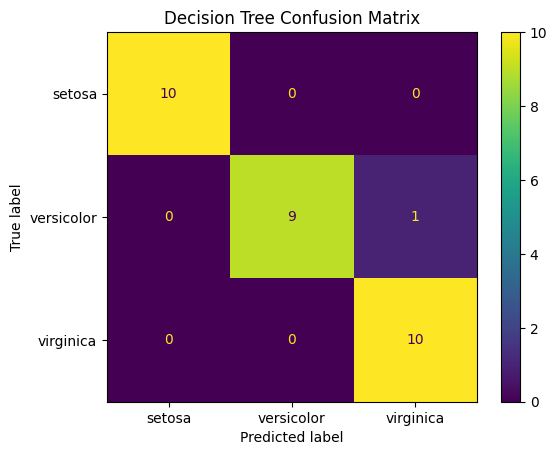

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    display_labels=iris.target_names
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows the classification performance of the Decision Tree model.

The model correctly classified all 10 Setosa flowers and all 10 Virginica flowers. It correctly classified 9 out of 10 Versicolor flowers, while one Versicolor flower was incorrectly classified as Virginica.

Therefore, the Decision Tree correctly classified 29 out of the 30 test samples.


In [59]:
model_names = [
    "Logistic Regression",
    "KNN",
    "Decision Tree"
]

model_accuracies = [
    93.33,
    93.33,
    96.67
]

for model, acc in zip(model_names, model_accuracies):
    print(f"{model}: {acc}%")

Logistic Regression: 93.33%
KNN: 93.33%
Decision Tree: 96.67%


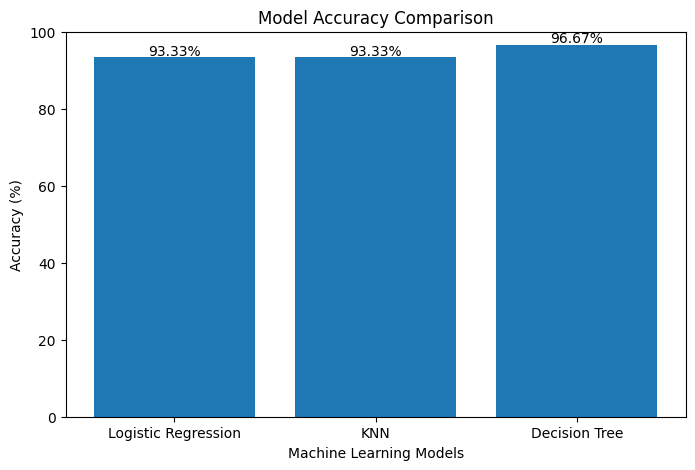

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(model_names, model_accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)

for i, accuracy_value in enumerate(model_accuracies):
    plt.text(
        i,
        accuracy_value + 0.5,
        f"{accuracy_value:.2f}%",
        ha="center"
    )

plt.show()

## Results

Three machine learning classification algorithms were trained and evaluated using the Iris dataset.

Logistic Regression achieved an accuracy of 93.33%, while K-Nearest Neighbors (KNN) also achieved an accuracy of 93.33%.

The Decision Tree classifier achieved the highest test accuracy of 96.67%.

The Decision Tree correctly classified 29 out of 30 test samples. It correctly classified all Setosa and Virginica test samples, while one Versicolor sample was incorrectly classified as Virginica.

Based on this experiment, the Decision Tree produced the highest test accuracy among the three models tested.


## Conclusion

In this project, machine learning techniques were used to classify Iris flowers into three species: Setosa, Versicolor, and Virginica.

The Iris dataset was loaded, explored, and visualized before being divided into training and testing sets.

Three machine learning classification algorithms were implemented: Logistic Regression, K-Nearest Neighbors, and Decision Tree.

Logistic Regression and KNN both achieved an accuracy of 93.33%, while the Decision Tree achieved an accuracy of 96.67%.

The Decision Tree correctly classified 29 out of 30 test samples and achieved the highest test accuracy among the three models in this experiment.

This project provided practical experience in data exploration, visualization, classification, model training, prediction, and model evaluation.
